In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. 加载数据
# 加载sklearn自带的红酒数据集对象, 它类似于一个字典
wine = load_wine()
# 获取特征数据矩阵(自变量), 通常包含酒精浓度、苹果酸等13个特征
X = wine.data
# 获取目标变量(因变量), 既红酒的类别 (0, 1, 2 三种类别)
y = wine.target

# 打印基本信息
# 打印数据集中所有特征(列)的名称
print(f"特征列表: {wine.feature_names}")
# 打印目标分类的名称 (例如: class_0, class_1, class_2)
print(f"类别列表: {wine.target_names}")

# 2. 分割数据集
# 将数据分为训练集和测试集
# test_size=0.3: 表示测试集占总数据的30%, 训练集占70%
# random_state=0: 设置随机种子, 保证每次迭代代码时分割的结果都是一样的, 便于复现
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
clf = RandomForestClassifier(n_estimators = 100,random_state = 0,n_jobs = 1)
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)

print('=' * 30) 
print(f'测试集准确率（Accuracy）：{accuracy:.4f}')
print('=' * 30) 
print('特征重要性排序')
feature_importances = pd.DataFrame(
    clf.feature_importances_,
    index = wine.feature_names,
    columns = ['importance']
).sort_values('importance',ascending = False)
print(feature_importances)

特征列表: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
类别列表: ['class_0' 'class_1' 'class_2']
测试集准确率（Accuracy）：0.9815
特征重要性排序
                              importance
color_intensity                 0.194819
proline                         0.164348
flavanoids                      0.145228
od280/od315_of_diluted_wines    0.119075
alcohol                         0.088747
hue                             0.080266
total_phenols                   0.061579
alcalinity_of_ash               0.039190
malic_acid                      0.029782
proanthocyanins                 0.023107
magnesium                       0.022962
ash                             0.016638
nonflavanoid_phenols            0.014258


开始训练，树的数量范围: 15 ~ 200, 步长: 5 ...
正在训练: 随机森林, max_features='sqrt' ...
[随机森林, max_features='sqrt'] 训练耗时: 1.4911秒
正在训练: 随机森林, max_features='log2' ...
[随机森林, max_features='log2'] 训练耗时: 1.4744秒
正在训练: 随机森林, max_features=None ...
[随机森林, max_features=None] 训练耗时: 1.4449秒


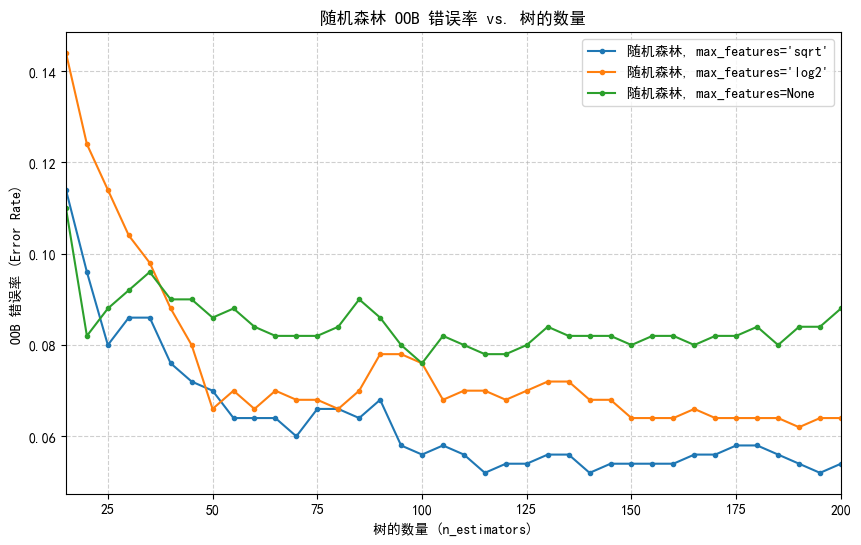

In [2]:
import matplotlib.pyplot as plt
# make_classification 用于生成分类数据集，这是一个用于分类任务的随机数据生成器
from sklearn.datasets import make_classification
# RandomForestClassifier 随机森林分类器
from sklearn.ensemble import RandomForestClassifier
from collections import OrderedDict
import time

# ============================
# 数据生成与参数设置
# ============================

plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

# 设置随机状态，保证每次运行生成的随机数和随机森林的构建过程是一致的，便于复现
RANDOM_STATE = 123

# 1. 生成数据集
# make_classification 生成一个二分类（默认）的分类数据集
# n_samples=500: 样本数量 500
# n_features=25: 特征数量 25 (总的特征数量)
# n_clusters_per_class=1: 每个类别的簇数量 (控制数据的分离度)
# n_informative=15: 信息特征的数量 (即实际对分类有帮助的特征数量，其余为噪声)
# random_state=RANDOM_STATE: 随机数种子
X, y = make_classification(n_samples=500, n_features=25,
                           n_clusters_per_class=1, n_informative=15,
                           random_state=RANDOM_STATE)

# 2. 定义分类器配置
# 使用 OrderedDict (有序字典) 来存储，保证遍历顺序与插入顺序一致 (Python 3.7+ 默认字典有序，但在旧版本中需要)
# 这里定义了三种不同 max_features 设置的随机森林
ensemble_clfs = [
    (
        "随机森林, max_features='sqrt'",
        RandomForestClassifier(
            warm_start=True,        # 【重要】设置为True，允许在现有森林的基础上添加树，而不是重新训练
            oob_score=True,         # 使用袋外样本来估计泛化误差 (OOB Score)
            max_features="sqrt",    # 每次分裂时，随机选择 sqrt(n_features) 个特征
            n_jobs=-1,              # 使用所有CPU核心并行计算
            random_state=RANDOM_STATE
        )
    ),
    (
        "随机森林, max_features='log2'",
        RandomForestClassifier(
            warm_start=True,
            oob_score=True,
            max_features="log2",    # 每次分裂时，随机选择 log2(n_features) 个特征
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    ),
    (
        "随机森林, max_features=None", # (原文图片可能是 None 或其他，根据上下文推断是 None，即所有特征)
        RandomForestClassifier(
            warm_start=True,
            oob_score=True,
            max_features=None,      # 每次分裂时，考虑所有特征 (max_features=n_features)
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    )
]

# Map a label (the string above) to a list of (n_estimators, error_rate) pairs.
error_rate = OrderedDict((label, []) for label, _ in ensemble_clfs)

# ============================
# 模型训练与误差记录
# ============================

min_estimators = 15   # 最小树的数量
max_estimators = 200  # 最大树的数量
step_size = 5         # 步长 (每次增加5棵树)

print(f"开始训练，树的数量范围: {min_estimators} ~ {max_estimators}, 步长: {step_size} ...")

# 遍历每一个定义的分类器
for label, clf in ensemble_clfs:
    start_time = time.time()
    print(f"正在训练: {label} ...")
    
    # 循环增加树的数量
    for i in range(min_estimators, max_estimators + 1, step_size):
        # 设置当前的树的数量 (n_estimators)
        clf.set_params(n_estimators=i)
        
        # 训练模型
        # 由于 warm_start=True，调用 fit 会在现有的树基础上添加新的树，而不是从头开始
        clf.fit(X, y)

        # 记录 OOB 错误率
        # oob_score_ 是准确率，所以 1 - oob_score_ 就是错误率 (Error Rate)
        oob_error = 1 - clf.oob_score_
        
        # 将 (树的数量, 错误率) 存入列表
        error_rate[label].append((i, oob_error))

    end_time = time.time()
    print(f"[{label}] 训练耗时: {end_time - start_time:.4f}秒")

# ============================
# 绘图 (可视化)
# ============================

# 设置画布大小
plt.figure(figsize=(10, 6), dpi=100)

# 遍历数据，绘制每一条曲线
for label, clf_err in error_rate.items():
    # xs: x轴数据 (n_estimators)
    # ys: y轴数据 (OOB Error Rate)
    xs, ys = zip(*clf_err)
    
    # 绘制曲线
    # label=label:图例名称
    plt.plot(xs, ys, label=label, marker='.', linewidth=1.5)

# 设置图表装饰
plt.xlim(min_estimators, max_estimators) # x轴范围
plt.xlabel("树的数量 (n_estimators)")
plt.ylabel("OOB 错误率 (Error Rate)")
plt.title("随机森林 OOB 错误率 vs. 树的数量") # 标题
plt.grid(True, linestyle='--', alpha=0.6) # 网格线
plt.legend(loc="upper right") # 图例位置

# 保存图片 (可选，代码中未显示保存，但为了完整性通常会加)
# plt.savefig("oob_error_vs_trees.png")

plt.show()

开始 Bagging 训练，迭代中...


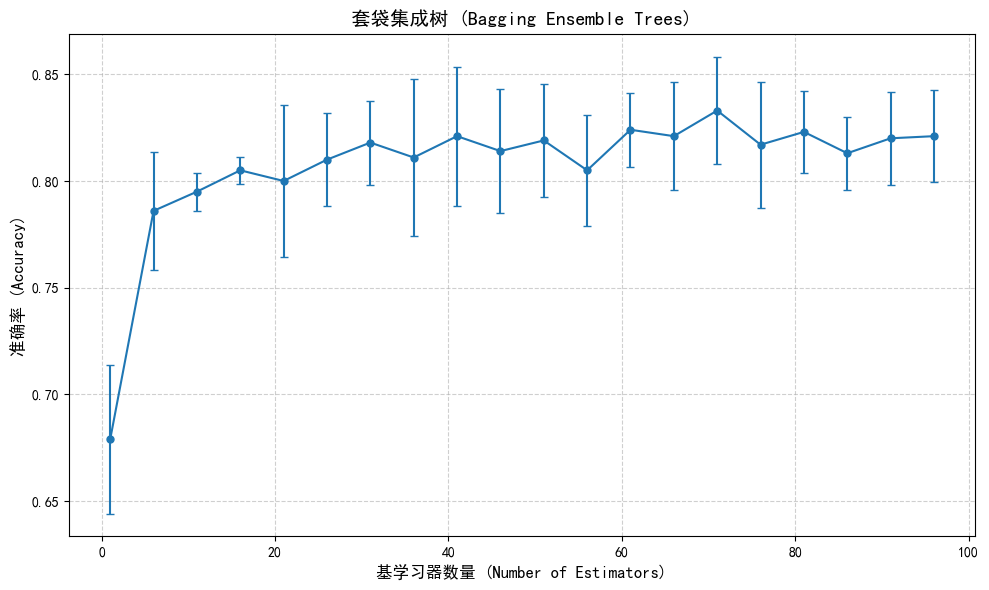

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# ==========================================
# 1. 基础参数设置
# ==========================================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# ==========================================
# 2. 生成数据
# ==========================================
# 为了模拟更复杂的分类问题，生成一个 1000 样本、20 特征的数据集
# n_samples=1000: 样本数量
# n_features=20: 特征数量
# flip_y=0.1: 添加部分噪声标签，增加分类难度 (10% 的标签是随机的)
# random_state=123: 锁定随机种子，保证结果可复现
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=2, flip_y=0.1, random_state=123)

# ==========================================
# 3. 训练与评估循环
# ==========================================
# 定义基分类器数量范围：从 1 到 101 (不含)，步长为 5
n_estimators_range = range(1, 101, 5)

# 用于存储每个数量对应的 平均准确率(means) 和 标准差(stds)
means = []
stds = []

print("开始 Bagging 训练，迭代中...")

for n_val in n_estimators_range:
    # 构建 Bagging 分类器
    # estimator: 基分类器，这里使用决策树 (DecisionTreeClassifier)
    # n_estimators: 基分类器的数量
    # random_state: 这里的随机种子不需要固定，允许内部随机性以发挥集成优势
    # 注意：在较旧的 sklearn 版本中参数名为 base_estimator，新版为 estimator
    clf = BaggingClassifier(estimator=DecisionTreeClassifier(),
                            n_estimators=n_val,
                            n_jobs=-1) # -1 表示使用所有 CPU 核心

    # 使用 5 折交叉验证 (Cross Validation) 计算得分
    # cv=5: 将数据分为 5 份，轮流验证，返回 5 个准确率分数
    scores = cross_val_score(clf, X, y, cv=5)

    # 记录平均得分
    means.append(np.mean(scores))
    # 记录标准差
    stds.append(np.std(scores))

# ==========================================
# 4. 绘图
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# 使用 errorbar 绘制带误差棒的折线图
# x: 树的数量
# y: 平均准确率
# yerr: 误差范围 (标准差)
# fmt='-o': 线型为实线，数据点标记为圆点
# capsize=3: 误差棒上下横线的长度
plt.errorbar(n_estimators_range, means, yerr=stds, fmt='-o', capsize=3, linewidth=1.5, markersize=5)

# 添加标题
plt.title('套袋集成树 (Bagging Ensemble Trees)', fontsize=14, fontweight='bold')

# 设置 X 轴标签
plt.xlabel('基学习器数量 (Number of Estimators)', fontsize=12)

# 设置 Y 轴标签
plt.ylabel('准确率 (Accuracy)', fontsize=12)

# 设置 Y 轴范围 (根据图片推测)
# plt.ylim(0.65, 0.90) # 图片代码中被注释或未完全显示，可根据需要开启

# 添加网格线，方便读数
plt.grid(True, linestyle='--', alpha=0.6)

# 自动调整布局
plt.tight_layout()

# 显示图片
plt.show()